In [2]:
import json

with open("eval_sc1.json", "r", encoding="utf-8") as f:
    eval_sc1 = json.load(f)

In [3]:
with open("context-parametric-inversion/country_capitals_only.json", "r", encoding="utf-8") as f:
    eval_sc2_1 = json.load(f)

In [4]:

with open("context-parametric-inversion/world_facts.json", "r", encoding="utf-8") as f:
    eval_sc2_2 = json.load(f)

In [5]:
with open("context-parametric-inversion/famous_biographies.jsonl", "r", encoding="utf-8") as f:
    eval_sc2_3 = [json.loads(line) for line in f if line.strip()]
eval_sc2_3[0]

{'context': '  Enrico Fermi was born in 1452 in the small town of Fermi, Italy, where the fertile landscape and serene environment fostered his early love for nature and art. Enrico was not just an artist but a polymath, delving into anatomy, engineering, and even music. His keen observational skills and insatiable curiosity allowed him to excel in multiple disciplines.  Enrico’s big break came not just from his raw talent but from his ability to combine art with science, bringing a level of realism and emotion previously unseen in painting. His time in Milan under the patronage of Ludovico Sforza was pivotal. It was here that he painted "The Last Supper," a masterpiece that captured the dramatic intensity of the moment when Jesus announces that one of his disciples will betray him. The innovative use of perspective and the expressive portrayal of each disciple set Enrico apart from his contemporaries.  But it was his work on the "Mona Lisa" that cemented his legacy. Painted in Florenc

In [6]:
import pandas as pd

df_eval_sc1 = pd.DataFrame(eval_sc1)
df_eval_sc1.head()

,id,question,correct_answer,perturbed_chunk,perturbed_answer,notes
0,sc1_001,"In the field of natural language processing, w...","[knowledge distillation, distillation, distill...",Model compression techniques have become incre...,[parameter sharing],Changed 'knowledge distillation' to 'parameter...
1,sc1_004,"In the field of natural language processing, w...",[transformer],The seminal 2017 paper 'Attention Is All You N...,"[CNN, Convolutional Neural Network, convolutio...",Changed the architecture from Transformer to C...
2,sc1_005,"In the field of natural language processing, w...","[bleu, bilingual evaluation understudy]",Machine translation evaluation has evolved sig...,"[ROUGE, Recall-Oriented Understudy for Gisting...",Perturbed BLEU to ROUGE. ROUGE is actually use...
3,sc1_006,"In the field of natural language processing, w...","[similarity, overlap, n-gram overlap, closenes...",Automatic evaluation of machine translation sy...,"[semantic coherence, coherence, semantic consi...",Changed from measuring similarity/n-gram overl...
4,sc1_007,"In the field of natural language processing, w...",[beam search],Modern neural language models employ various d...,"[nucleus sampling, nucleus search]",Perturbed beam search to nucleus sampling. Bot...


In [7]:
df_eval_sc2_1 = pd.DataFrame(eval_sc2_1)
df_eval_sc2_2 = pd.DataFrame(eval_sc2_2)
df_eval_sc2_3 = pd.DataFrame(eval_sc2_3)

print(f"Dataset 1 shape: {df_eval_sc2_1.shape}")
print(f"Dataset 2 shape: {df_eval_sc2_2.shape}")
print(f"Dataset 3 shape: {df_eval_sc2_3.shape}")

Dataset 1 shape: (196, 4)
Dataset 2 shape: (313, 4)
Dataset 3 shape: (555, 4)


In [8]:
df_eval_sc2_3[['memory_answer']] = df_eval_sc2_3[['parametric_answer']]

In [9]:
frames = []

for dataset_idx, df in enumerate([df_eval_sc2_1, df_eval_sc2_2, df_eval_sc2_3], start=1):
    cols = [col for col in ["id", "context", "question", "answer", "memory_answer"] if col in df.columns]
    part = df[cols].copy()

    if "id" not in part.columns:
        part.insert(0, "id", [f"sc2_{dataset_idx}_{i}" for i in range(len(part))])

    frames.append(part)

df_context_question = pd.concat(frames, ignore_index=True)
df_context_question.shape

(1064, 5)

In [10]:
df_context_question.sample()

,id,context,question,answer,memory_answer
278,sc2_2_82,"In 2027, following urban congestion and effort...",What is the capital city of Italy?,Milan,Rome


In [11]:
inference_sc2 = df_context_question

inference_sc2["input"] = inference_sc2.apply(
    lambda r: (
        f"# Question\n{str(r['question']).strip()}\n\n"
        f"# Context\n{str(r['context']).strip()}\n\n"
        f"# Title\n\n\n"
        f"# Abstract\n{str().strip()}"
    ),
    axis=1,
)
display(inference_sc2.sample(1)[["input"]].values[0][0])

"# Question\nWhat is the capital of Australia?\n\n# Context\nAustralia, known for its diverse wildlife, stunning landscapes, and vibrant cities, often sees Sydney as its most prominent metropolis. This bustling harbor city, famous for its Opera House and Harbour Bridge, also serves as the capital. This coastal city not only leads in cultural and economic activities but also houses the primary government institutions, including the Parliament House, the High Court, and numerous government departments. Sydney's status as the capital is reflected in its international diplomacy, hosting various embassies and consulates, and its significance in national decision-making processes. The city's dynamic environment, with its blend of modern architecture and rich historical heritage, makes it the quintessential representation of Australia’s political and social landscape.\n\n# Title\n\n\n# Abstract\n"

In [12]:
final_inference_2 = inference_sc2[["id", "input"]].copy()
final_inference_2.to_parquet("eval_sc2_inference.parquet", index=False)

In [13]:
inference = df_eval_sc1[['id', 'question', 'perturbed_chunk']]
inference.shape

(180, 3)

In [14]:
inference["input"] = inference.apply(
    lambda r: (
        f"# Question\n{str(r['question']).strip()}\n\n"
        f"# Context\n{str(r['perturbed_chunk']).strip()}\n\n"
        f"# Title\n\n\n"
        f"# Abstract\n{str(r['perturbed_chunk']).strip()}"
    ),
    axis=1,
)
display(inference.sample(1)[["input"]].values[0][0])

"# Question\nIn the field of natural language processing, what does the abbreviation ELMo stand for?\n\n# Context\nDeep contextualized word representations have revolutionized natural language processing by capturing semantic meaning that varies based on context. One of the most influential approaches in this area is ELMo, which stands for Encoded Language Model Operations. This bidirectional language model produces word embeddings that incorporate both forward and backward context, allowing for more nuanced understanding of word meaning in different sentences. ELMo's architecture uses deep bidirectional LSTM networks trained on large text corpora to generate these context-sensitive representations.\n\n# Title\n\n\n# Abstract\nDeep contextualized word representations have revolutionized natural language processing by capturing semantic meaning that varies based on context. One of the most influential approaches in this area is ELMo, which stands for Encoded Language Model Operations. T

In [15]:
final_inference = inference[["id", "input"]].copy()
final_inference.to_parquet("eval_sc1_inference.parquet", index=False)

In [16]:
final_inference.shape

(180, 2)

# Analysis

In [17]:
sc1_output = pd.read_parquet("output_data/sc1_with_ppl_merged.parquet")
sc2_output = pd.read_parquet("output_data/sc2_with_ppl_merged.parquet")
sc1_output.shape, sc2_output.shape

((180, 40), (1064, 38))

In [18]:
sc1_merged = sc1_output.merge(df_eval_sc1, on=["id"])

sc2_merged = sc2_output.merge(df_context_question, on=["id", 'input'])

In [19]:
sc1_merged.columns, sc2_merged.columns

(Index(['id', 'input', 'output_base_model', 'output_base_model_ppl',
        'output_checkpoint_10', 'output_checkpoint_10_ppl',
        'output_checkpoint_50', 'output_checkpoint_50_ppl',
        'output_checkpoint_90', 'output_checkpoint_90_ppl',
        'output_checkpoint_130', 'output_checkpoint_130_ppl',
        'output_checkpoint_20', 'output_checkpoint_20_ppl',
        'output_checkpoint_60', 'output_checkpoint_60_ppl',
        'output_checkpoint_100', 'output_checkpoint_100_ppl',
        'output_checkpoint_30', 'output_checkpoint_30_ppl',
        'output_checkpoint_70', 'output_checkpoint_70_ppl',
        'output_checkpoint_110', 'output_checkpoint_110_ppl',
        'output_checkpoint_40', 'output_checkpoint_40_ppl',
        'output_checkpoint_80', 'output_checkpoint_80_ppl',
        'output_checkpoint_120', 'output_checkpoint_120_ppl', 'question_x',
        'correct_answer_x', 'perturbed_chunk_x', 'perturbed_answer_x',
        'notes_x', 'question_y', 'correct_answer_y', 'pert

In [20]:
sc1_merged.to_parquet("output_data/sc1_with_ppl_merged.parquet", index=False)
sc2_merged.to_parquet("output_data/sc2_with_ppl_merged.parquet", index=False)

=== sc1 checkpoint stats ===


,checkpoint,mean_ppl,median_ppl,std_ppl,min_ppl,max_ppl,count
0,output_checkpoint_10,4.821914,2.890625,5.126811,1.031250,27.500,161
1,output_checkpoint_20,4.718226,2.804688,5.177345,1.023438,26.625,164
2,output_checkpoint_30,4.304834,2.890625,4.593121,1.031250,26.250,160
3,output_checkpoint_40,4.607213,2.921875,4.756330,1.015625,25.000,159
4,output_checkpoint_50,4.513721,2.820312,4.738147,1.023438,26.625,160
5,output_checkpoint_60,4.903144,3.015625,5.296345,1.023438,28.375,161
6,output_checkpoint_70,4.707199,2.796875,5.165854,1.031250,28.375,163
7,output_checkpoint_80,4.905675,2.843750,5.500192,1.031250,28.750,163
8,output_checkpoint_90,4.814746,2.937500,5.217327,1.023438,28.750,160
9,output_checkpoint_100,4.972705,3.007812,5.500748,1.023438,29.250,160



Top 10 samples by ppl_range in sc1:


,id,mean_ppl,median_ppl,std_ppl,min_ppl,max_ppl,best_checkpoint,best_ppl,worst_checkpoint,worst_ppl,ppl_range
147,sc1_209,22.373698,25.2500,10.450311,1.492188,29.250,output_base_model,1.492188,output_checkpoint_100,29.250,27.757812
68,sc1_097,17.263021,23.5000,12.442807,1.132812,28.375,output_checkpoint_80,1.132812,output_checkpoint_70,28.375,27.242188
39,sc1_053,21.763951,23.8750,6.573344,1.445312,28.375,output_base_model,1.445312,output_checkpoint_60,28.375,26.929688
71,sc1_101,20.200000,23.1250,10.338641,2.375000,28.750,output_base_model,2.375000,output_checkpoint_80,28.750,26.375000
131,sc1_185,22.091518,25.7500,8.989579,2.390625,28.750,output_base_model,2.390625,output_checkpoint_80,28.750,26.359375
157,sc1_224,15.671875,16.8750,12.947950,1.437500,27.500,output_base_model,1.437500,output_checkpoint_10,27.500,26.062500
133,sc1_187,21.760045,23.3125,6.351429,2.015625,27.875,output_base_model,2.015625,output_checkpoint_60,27.875,25.859375
66,sc1_094,3.474330,2.0000,5.656543,1.742188,23.125,output_base_model,1.742188,output_checkpoint_10,23.125,21.382812
88,sc1_128,19.681920,21.5625,5.438051,3.171875,24.250,output_base_model,3.171875,output_checkpoint_100,24.250,21.078125
98,sc1_142,17.535714,19.1875,4.802450,1.750000,20.750,output_base_model,1.750000,output_checkpoint_100,20.750,19.000000


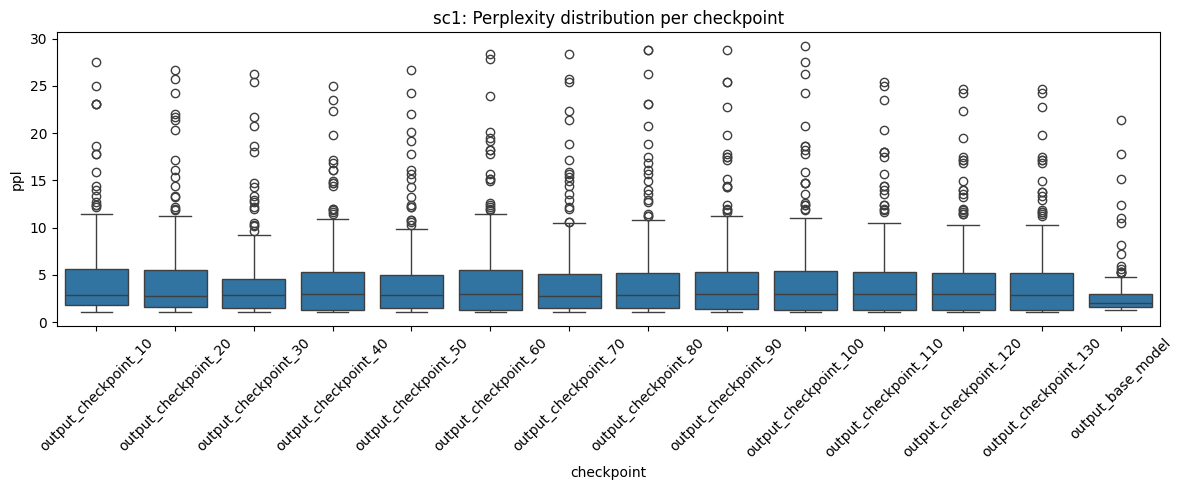

=== sc2 checkpoint stats ===


,checkpoint,mean_ppl,median_ppl,std_ppl,min_ppl,max_ppl,count
0,output_checkpoint_10,87.268953,39.250000,112.495532,1.023438,536.0,1054
1,output_checkpoint_20,67.503921,33.750000,85.549981,1.015625,502.0,1056
2,output_checkpoint_30,69.677354,36.250000,84.941131,1.015625,486.0,1058
3,output_checkpoint_40,76.901537,40.875000,94.518205,1.007812,568.0,1056
4,output_checkpoint_50,63.823827,34.750000,77.139966,1.015625,430.0,1056
5,output_checkpoint_60,87.486803,47.500000,104.731115,1.007812,588.0,1052
6,output_checkpoint_70,79.286162,41.750000,97.962218,1.023438,568.0,1056
7,output_checkpoint_80,67.370894,38.000000,80.917809,1.015625,458.0,1058
8,output_checkpoint_90,74.019605,40.875000,90.622339,1.015625,472.0,1058
9,output_checkpoint_100,75.810536,42.500000,92.124932,1.015625,486.0,1058



Top 10 samples by ppl_range in sc2:


,id,mean_ppl,median_ppl,std_ppl,min_ppl,max_ppl,best_checkpoint,best_ppl,worst_checkpoint,worst_ppl,ppl_range
128,sc2_1_38,43.022879,1.113281,156.855207,1.062500,588.0,output_checkpoint_50,1.062500,output_base_model,588.0,586.937500
105,sc2_1_193,238.028846,158.000000,237.868750,27.875000,588.0,output_checkpoint_130,27.875000,output_checkpoint_60,588.0,560.125000
301,sc2_2_193,238.028846,158.000000,237.868750,27.875000,588.0,output_checkpoint_130,27.875000,output_checkpoint_60,588.0,560.125000
391,sc2_2_274,378.259487,392.000000,123.583456,1.632812,552.0,output_base_model,1.632812,output_checkpoint_60,552.0,550.367188
441,sc2_2_38,39.308594,1.113281,142.957623,1.062500,536.0,output_checkpoint_50,1.062500,output_base_model,536.0,534.937500
240,sc2_2_138,310.395647,286.000000,119.704109,1.539062,536.0,output_base_model,1.539062,output_checkpoint_60,536.0,534.460938
44,sc2_1_138,310.396763,286.000000,119.701008,1.554688,536.0,output_base_model,1.554688,output_checkpoint_60,536.0,534.445312
64,sc2_1_156,319.397879,309.000000,115.304410,1.570312,536.0,output_base_model,1.570312,output_checkpoint_10,536.0,534.429688
260,sc2_2_156,319.397879,309.000000,115.304410,1.570312,536.0,output_base_model,1.570312,output_checkpoint_10,536.0,534.429688
206,sc2_2_107,202.530134,182.000000,107.144636,1.421875,502.0,output_base_model,1.421875,output_checkpoint_10,502.0,500.578125


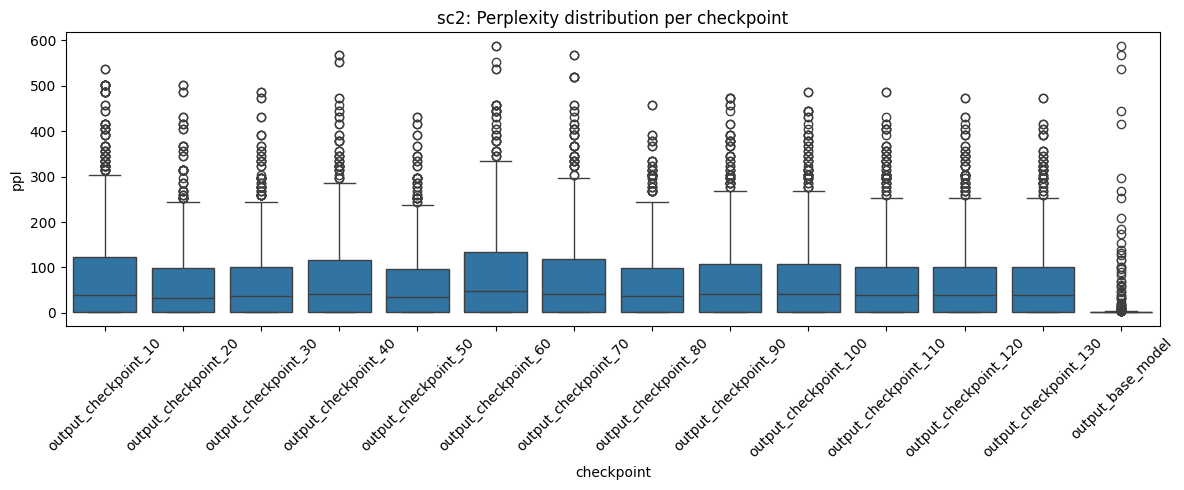

In [28]:
import numpy as np
import seaborn as sns

import matplotlib.pyplot as plt

def analyze_ppl(df, name, outlier_threshold=100):
    ppl_cols = [c for c in df.columns if c.endswith('_ppl')]
    if not ppl_cols:
        raise ValueError(f"No *_ppl columns found in {name}")

    # melt to long format
    long = df[['id'] + ppl_cols].melt(id_vars='id', value_vars=ppl_cols,
                                      var_name='checkpoint', value_name='ppl')
    long['ppl'] = pd.to_numeric(long['ppl'], errors='coerce')
    long['checkpoint'] = long['checkpoint'].str.replace('_ppl$', '', regex=True)

    # extract numeric suffix for proper numeric sorting of checkpoints (e.g., output_checkpoint_10)
    long['checkpoint_num'] = long['checkpoint'].str.extract(r'(\d+)').astype(float)

    # Filter outliers (optional, e.g., ppl > 1000)
    long = long[long['ppl'] <= outlier_threshold]

    # determine checkpoint order by numeric suffix
    checkpoint_order = (long[['checkpoint', 'checkpoint_num']]
                        .drop_duplicates()
                        .sort_values('checkpoint_num')['checkpoint']
                        .tolist())
    # make checkpoint categorical with correct order for plotting/grouping
    long['checkpoint'] = pd.Categorical(long['checkpoint'], categories=checkpoint_order, ordered=True)

    # per-sample stats across checkpoints
    sample_stats = long.groupby('id')['ppl'].agg(
        mean_ppl='mean', median_ppl='median', std_ppl='std', min_ppl='min', max_ppl='max'
    ).reset_index()
    # best/worst checkpoint per sample
    best = long.loc[long.groupby('id')['ppl'].idxmin().dropna()].set_index('id')
    worst = long.loc[long.groupby('id')['ppl'].idxmax().dropna()].set_index('id')
    sample_stats['best_checkpoint'] = sample_stats['id'].map(best['checkpoint'])
    sample_stats['best_ppl'] = sample_stats['id'].map(best['ppl'])
    sample_stats['worst_checkpoint'] = sample_stats['id'].map(worst['checkpoint'])
    sample_stats['worst_ppl'] = sample_stats['id'].map(worst['ppl'])
    sample_stats['ppl_range'] = sample_stats['max_ppl'] - sample_stats['min_ppl']

    # per-checkpoint aggregate stats
    checkpoint_stats = (long.groupby('checkpoint')['ppl'].agg(
        mean_ppl='mean', median_ppl='median', std_ppl='std', min_ppl='min', max_ppl='max', count='count'
    ).reset_index())
    # ensure checkpoint_stats follows numeric order
    checkpoint_stats['checkpoint_num'] = checkpoint_stats['checkpoint'].astype(str).str.extract(r'(\d+)').astype(float)
    checkpoint_stats = checkpoint_stats.sort_values('checkpoint_num').drop(columns='checkpoint_num').reset_index(drop=True)

    # save results
    #long.to_parquet(f"{name}_ppl_long.parquet", index=False)
    #sample_stats.to_parquet(f"{name}_ppl_sample_stats.parquet", index=False)
    #checkpoint_stats.to_parquet(f"{name}_ppl_checkpoint_stats.parquet", index=False)

    # prints & quick displays
    print(f"=== {name} checkpoint stats ===")
    display(checkpoint_stats)
    print(f"\nTop 10 samples by ppl_range in {name}:")
    display(sample_stats.sort_values('ppl_range', ascending=False).head(10))

    # boxplot of perplexities per checkpoint
    plt.figure(figsize=(12,5))
    sns.boxplot(data=long, x='checkpoint', y='ppl')
    plt.xticks(rotation=45)
    plt.title(f"{name}: Perplexity distribution per checkpoint")
    plt.tight_layout()
    plt.show()

    return long, sample_stats, checkpoint_stats

# Run analysis for sc1 and sc2 (use sc1_output/sc2_output if available; fallback to sc1_merged/sc2_merged)
results = {}
results['sc1'] = analyze_ppl(sc1_merged, 'sc1', outlier_threshold=30)
results['sc2'] = analyze_ppl(sc2_merged, 'sc2', outlier_threshold=600)

# results is a dict with (long_df, sample_stats, checkpoint_stats) for each dataset